## Insurance Claims

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_style("whitegrid") 

In [4]:
df=pd.read_csv("Insurance claims data.csv")

In [5]:
df.shape

(58592, 41)

In [6]:
df.head(3)

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0


In [7]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera',
       'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight',
       'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert',
       'ncap_rating', 'claim_status'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  str    
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  str    
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  str    
 7   model                             58592 non-null  str    
 8   fuel_type                         58592 non-null  str    
 9   max_torque                        58592 non-null  str    
 10  max_power                         58592 non-null  str    
 11  engine_type                       58592 non-null  str    
 12  airbags        

In [9]:
df["claim_status"].value_counts()

claim_status
0    54844
1     3748
Name: count, dtype: int64

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
(df["claim_status"].value_counts(normalize=True) * 100).round(2) 


claim_status
0    93.6
1     6.4
Name: proportion, dtype: float64

In [13]:
num_cols = df.select_dtypes(include= [ "int64" , "float64" ]).columns.to_list()

In [14]:
len(num_cols)

13

In [30]:
obj_cols = df.select_dtypes(include= [ "object" ]).columns.to_list()

In [16]:
len(obj_cols)

28

In [17]:
df.head(2)

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0


In [18]:
num_cols.remove("claim_status")
obj_cols.remove("policy_id")

In [19]:
for col in obj_cols:
    
    uniques = df[col].unique()
    print(f"{col:35s} - unique_values: {df[col].nunique():3d} - sample: {uniques[:5]}")

region_code                         - unique_values:  22 - sample: <ArrowStringArray>
['C8', 'C2', 'C10', 'C13', 'C7']
Length: 5, dtype: str
segment                             - unique_values:   6 - sample: <ArrowStringArray>
['C2', 'C1', 'A', 'B2', 'B1']
Length: 5, dtype: str
model                               - unique_values:  11 - sample: <ArrowStringArray>
['M4', 'M9', 'M1', 'M5', 'M7']
Length: 5, dtype: str
fuel_type                           - unique_values:   3 - sample: <ArrowStringArray>
['Diesel', 'CNG', 'Petrol']
Length: 3, dtype: str
max_torque                          - unique_values:   9 - sample: <ArrowStringArray>
['250Nm@2750rpm', '200Nm@1750rpm', '60Nm@3500rpm', '200Nm@3000rpm', '113Nm@4400rpm']
Length: 5, dtype: str
max_power                           - unique_values:   9 - sample: <ArrowStringArray>
['113.45bhp@4000rpm', '97.89bhp@3600rpm', '40.36bhp@6000rpm', '88.77bhp@4000rpm', '88.50bhp@6000rpm']
Length: 5, dtype: str
engine_type                         - uniqu

In [20]:
binary_cols = [c for c in obj_cols if set(df[c].unique())  <= {"Yes","No"}]

In [21]:
binary_cols

['is_esc',
 'is_adjustable_steering',
 'is_tpms',
 'is_parking_sensors',
 'is_parking_camera',
 'is_front_fog_lights',
 'is_rear_window_wiper',
 'is_rear_window_washer',
 'is_rear_window_defogger',
 'is_brake_assist',
 'is_power_door_locks',
 'is_central_locking',
 'is_power_steering',
 'is_driver_seat_height_adjustable',
 'is_day_night_rear_view_mirror',
 'is_ecw',
 'is_speed_alert']

In [22]:
results = []

for col in binary_cols:
    rates = df.groupby(col)["claim_status"].mean() * 100 
    gap = abs(rates.get("Yes", 0) - rates.get("No", 0))
    results.append((col, rates.get("No", np.nan), rates.get("Yes", np.nan), gap))
     

In [23]:
results

[('is_esc',
  np.float64(6.347192157448185),
  np.float64(6.5050812455844795),
  np.float64(0.15788908813629465)),
 ('is_adjustable_steering',
  np.float64(5.97416110292205),
  np.float64(6.671170410403649),
  np.float64(0.6970093074815988)),
 ('is_tpms',
  np.float64(6.38713151164356),
  np.float64(6.42745042088743),
  np.float64(0.04031890924387049)),
 ('is_parking_sensors',
  np.float64(5.39401601348504),
  np.float64(6.439104217435386),
  np.float64(1.0450882039503453)),
 ('is_parking_camera',
  np.float64(6.413847187990142),
  np.float64(6.370150297098917),
  np.float64(0.043696890891225415)),
 ('is_front_fog_lights',
  np.float64(6.057411612066169),
  np.float64(6.643480311247347),
  np.float64(0.5860686991811779)),
 ('is_rear_window_wiper',
  np.float64(6.355382619974059),
  np.float64(6.49840783111216),
  np.float64(0.14302521113810052)),
 ('is_rear_window_washer',
  np.float64(6.355382619974059),
  np.float64(6.49840783111216),
  np.float64(0.14302521113810052)),
 ('is_rear_wi

In [24]:
gap_df = pd.DataFrame(results, columns=["Feature", "Claim_Rate_No", "Claim_Rate_Yes", "gap"]).sort_values("gap", ascending=False)
print(gap_df.round(2).to_string(index=False))

                         Feature  Claim_Rate_No  Claim_Rate_Yes  gap
                  is_speed_alert           4.13            6.41 2.28
              is_parking_sensors           5.39            6.44 1.05
          is_adjustable_steering           5.97            6.67 0.70
             is_front_fog_lights           6.06            6.64 0.59
                 is_brake_assist           6.10            6.64 0.54
is_driver_seat_height_adjustable           6.09            6.62 0.53
   is_day_night_rear_view_mirror           6.24            6.65 0.40
               is_power_steering           6.04            6.40 0.37
              is_central_locking           6.13            6.50 0.36
                          is_ecw           6.13            6.50 0.36
             is_power_door_locks           6.13            6.50 0.36
                          is_esc           6.35            6.51 0.16
            is_rear_window_wiper           6.36            6.50 0.14
           is_rear_window_washer  

C:\Users\Anshul\AppData\Local\Temp\ipykernel_9820\1554783626.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_df, y="Feature", x="gap", palette="viridis")


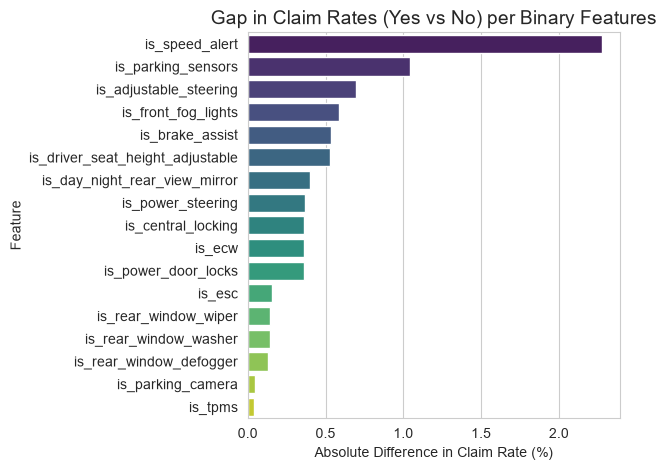

In [25]:
sns.barplot(data=gap_df, y="Feature", x="gap", palette="viridis")
plt.title("Gap in Claim Rates (Yes vs No) per Binary Features", fontsize=14)
plt.xlabel("Absolute Difference in Claim Rate (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
df.groupby("claim_status")[num_cols].mean().T.round(2)

claim_status,0,1
subscription_length,6.03,7.36
vehicle_age,1.40,1.27
customer_age,44.78,45.41
region_density,18909.07,17623.82
airbags,3.14,3.16
displacement,1161.82,1170.18
cylinder,3.63,3.65
turning_radius,4.85,4.86
length,3849.95,3858.21
width,1671.94,1676.50


In [27]:
cat_to_explore = ["region_code", "model", "segment", "fuel_type", "transmission_type", "steering_type"]

for col in cat_to_explore:
    
    grp = df.groupby(col)["claim_status"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    
    grp["mean"] = (grp["mean"] * 100).round(2)
    
    print(f"-----{col}-----")
    
    print(grp.head(10))

-----region_code-----
              mean  count
region_code              
C18          10.74    242
C22           8.21    207
C14           7.68   3660
C4            7.67    665
C21           7.65    379
C19           7.46    952
C3            7.10   6101
C2            7.08   7342
C8            6.99  13654
C6            6.18    890
-----model-----
       mean  count
model             
M2     7.41   1080
M5     7.26   1598
M7     6.84   2940
M6     6.82  13776
M4     6.43  14018
M9     6.29   2114
M1     6.14  14948
M10    6.04   1209
M8     5.85   4173
M3     5.39   2373
-----segment-----
         mean  count
segment             
B2       6.86  18314
C2       6.43  14018
C1       6.41   3557
A        6.04  17321
Utility  6.04   1209
B1       5.85   4173
-----fuel_type-----
           mean  count
fuel_type             
Petrol     6.64  20532
Diesel     6.49  17730
CNG        6.07  20330
-----transmission_type-----
                   mean  count
transmission_type             
Automatic  

In [28]:
import warnings
warnings.filterwarnings("ignore")   

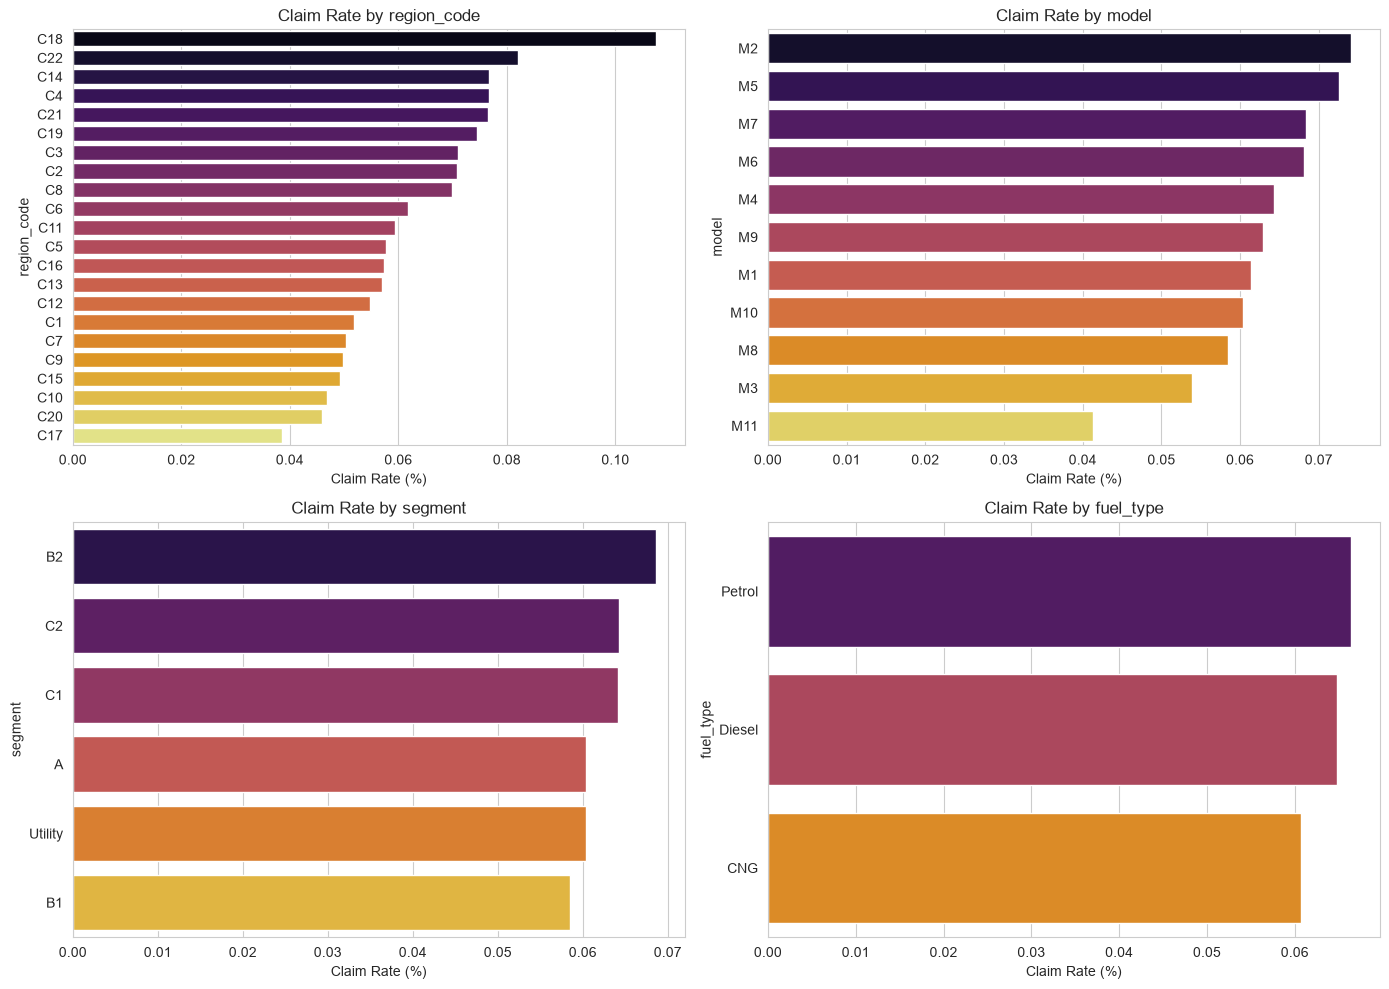

In [29]:
fig,  axes = plt.subplots(2, 2, figsize=(14, 10))


for ax, col in zip(axes.flat, ["region_code", "model", "segment", "fuel_type"]):
    
    grp = df.groupby(col)["claim_status"].mean().sort_values(ascending=False)
    
    sns.barplot(x=grp.values, y=grp.index, ax = ax, palette="inferno")
    ax.set_title(f"Claim Rate by {col}")
    ax.set_xlabel("Claim Rate (%)")
    
    
plt.tight_layout()
plt.show()

In [31]:
corr_cols = num_cols + ["claim_status"]

corr = df[corr_cols].corr()

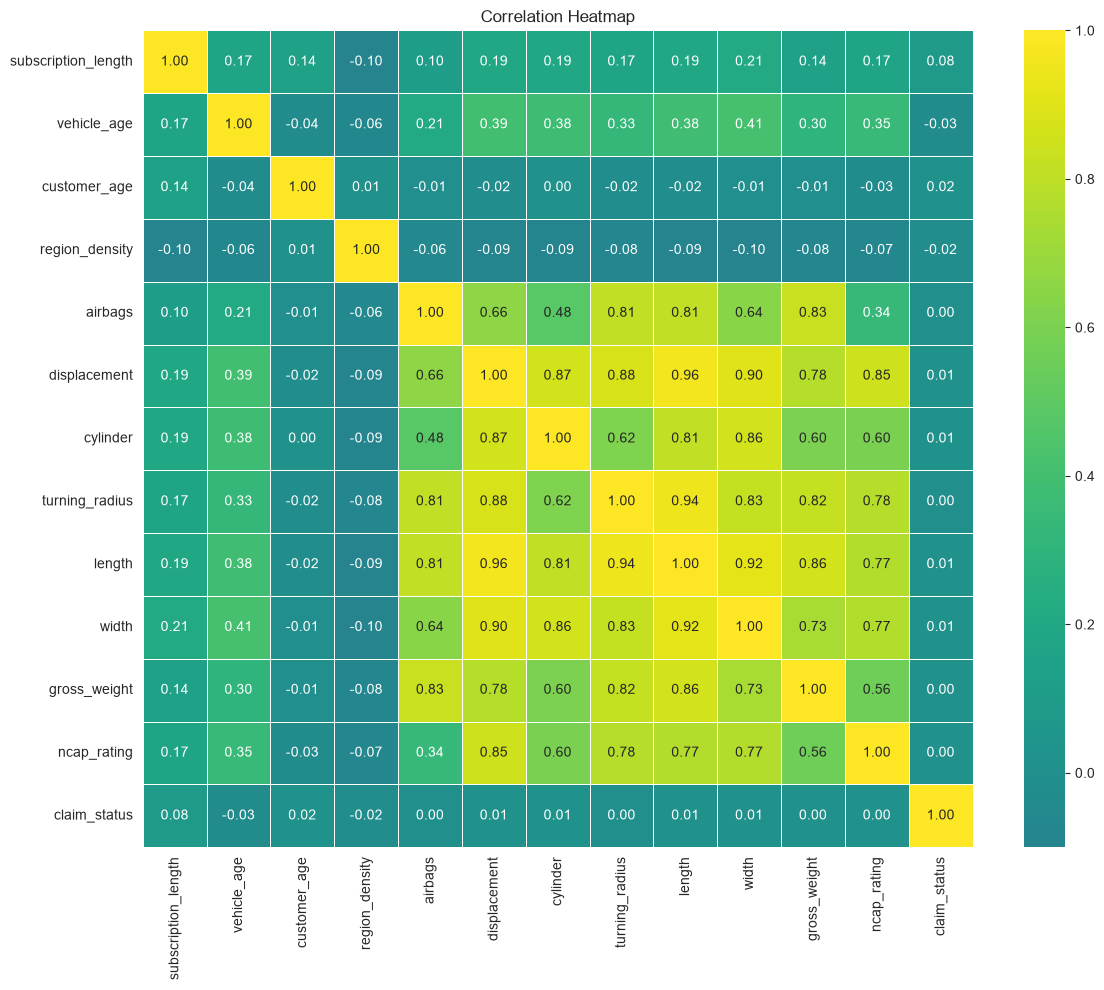

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", center = 0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [33]:
for col in ["subscription_length", "vehicle_age", "customer_age"]:
    
    print(f"-----{col}-----")
    print(df[col].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

-----subscription_length-----
count    58592.000000
mean         6.111688
std          4.142790
min          0.000000
1%           0.100000
5%           0.400000
25%          2.100000
50%          5.700000
75%         10.400000
95%         12.000000
99%         12.400000
max         14.000000
Name: subscription_length, dtype: float64
-----vehicle_age-----
count    58592.000000
mean         1.388473
std          1.134413
min          0.000000
1%           0.000000
5%           0.000000
25%          0.400000
50%          1.200000
75%          2.200000
95%          3.400000
99%          4.200000
max         20.000000
Name: vehicle_age, dtype: float64
-----customer_age-----
count    58592.000000
mean        44.823935
std          6.935604
min         35.000000
1%          35.000000
5%          35.000000
25%         39.000000
50%         44.000000
75%         49.000000
95%         58.000000
99%         63.000000
max         75.000000
Name: customer_age, dtype: float64


In [34]:
print(f"vehicle_age > 10", (df["vehicle_age"] > 10).sum())

vehicle_age > 10 6


In [35]:
(df["subscription_length"]== 0).sum()

np.int64(276)

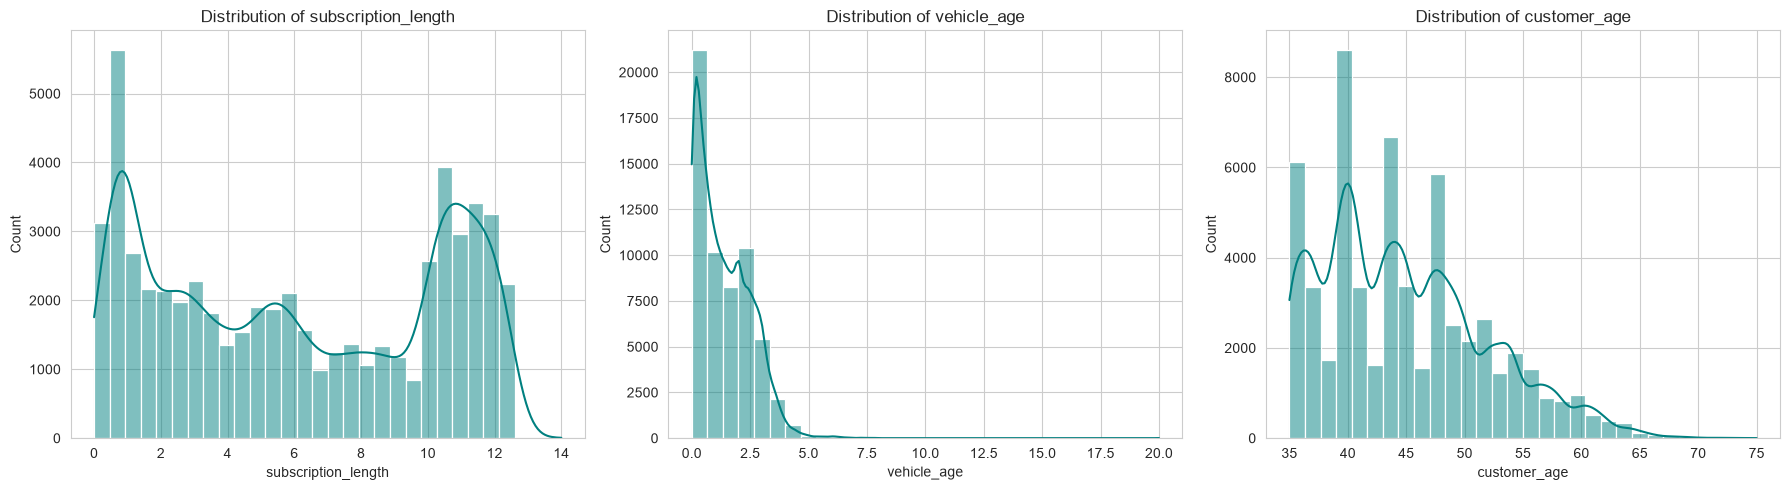

In [36]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, col in zip(axes, ["subscription_length", "vehicle_age", "customer_age"]):
    
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
    
plt.tight_layout()
plt.show()

In [37]:
df[["max_torque", "max_power"]]

,max_torque,max_power
0,250Nm@2750rpm,113.45bhp@4000rpm
1,200Nm@1750rpm,97.89bhp@3600rpm
2,250Nm@2750rpm,113.45bhp@4000rpm
3,60Nm@3500rpm,40.36bhp@6000rpm
4,200Nm@3000rpm,88.77bhp@4000rpm
...,...,...
58587,113Nm@4400rpm,88.50bhp@6000rpm
58588,250Nm@2750rpm,113.45bhp@4000rpm
58589,113Nm@4400rpm,88.50bhp@6000rpm
58590,113Nm@4400rpm,88.50bhp@6000rpm


In [38]:
torque_parsed = df["max_torque"].str.extract(r"([\d.]+)Nm@([\d.]+)rpm").astype(float)

In [39]:
torque_parsed

,0,1
0,250.0,2750.0
1,200.0,1750.0
2,250.0,2750.0
3,60.0,3500.0
4,200.0,3000.0
...,...,...
58587,113.0,4400.0
58588,250.0,2750.0
58589,113.0,4400.0
58590,113.0,4400.0


In [40]:
power_parsed = df["max_power"].str.extract(r"([\d.]+)bhp@([\d.]+)rpm").astype(float)

In [41]:
power_parsed

,0,1
0,113.45,4000.0
1,97.89,3600.0
2,113.45,4000.0
3,40.36,6000.0
4,88.77,4000.0
...,...,...
58587,88.50,6000.0
58588,113.45,4000.0
58589,88.50,6000.0
58590,88.50,6000.0


In [42]:
df["torque_Nm"]= torque_parsed[0]
df["torque_rpm"]= torque_parsed[1]
df["power_bhp"]= power_parsed[0]
df["power_rpm"]= power_parsed[1]

In [43]:
df

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status,torque_Nm,torque_rpm,power_bhp,power_rpm
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0,200.0,1750.0,97.89,3600.0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0,60.0,3500.0,40.36,6000.0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0,200.0,3000.0,88.77,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,POL019269,10.6,2.6,48,C5,34738,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0
58588,POL001254,2.3,2.2,37,C3,4076,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
58589,POL019859,6.6,2.2,35,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0
58590,POL014061,4.1,3.6,44,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0


In [44]:
torque_parsed.isna().any(axis=1).sum()

np.int64(0)

In [45]:
power_parsed.isna().any(axis=1).sum()

np.int64(0)

In [46]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera',
       'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight',
       'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert',
       'ncap_rating', 'claim_status', 'torque_Nm', 'torque_rpm', 'power_bhp', 'power_rpm'],
      dtype='str')

In [47]:
drop_cols = [
     'policy_id', 'segment', 'engine_type', 'fuel_type', 'max_torque', 'max_power',
     'torque_Nm', 'torque_rpm', 'power_bhp', 'power_rpm',
     'displacement', 'cylinder', 'turning_radius', 'length', 'width', 
     'gross_weight', 'ncap_rating', 'airbags', 'steering_type',
     'transmission_type', 'rear_brakes_type', 'is_esc', 'is_adjustable_steering', 
     'region_code',
     'is_tpms', 'is_parking_camera', 'is_rear_window_wiper', 'is_rear_window_washer',
     'is_rear_window_defogger', 'is_central_locking', 'is_power_door_locks', 'is_ecw',
]   

In [48]:
df_clean = df.drop(columns=drop_cols)

In [49]:
df_clean.columns

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'model', 'is_parking_sensors', 'is_front_fog_lights',
       'is_brake_assist', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_speed_alert',
       'claim_status'],
      dtype='str')

In [50]:
df_clean.shape

(58592, 13)

In [51]:
binary_final = ['is_parking_sensors', 'is_front_fog_lights', 'is_brake_assist',
                'is_power_steering', 'is_driver_seat_height_adjustable',
                'is_day_night_rear_view_mirror','is_speed_alert']

for col in binary_final:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

In [52]:
df_clean

,subscription_length,vehicle_age,customer_age,region_density,model,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,claim_status
0,9.3,1.2,41,8794,M4,1,1,1,1,1,0,1,0
1,8.2,1.8,35,27003,M9,1,1,0,1,1,1,1,0
2,9.5,0.2,44,8794,M4,1,1,1,1,1,0,1,0
3,5.2,0.4,44,73430,M1,1,0,0,1,0,0,1,0
4,10.1,1.0,56,5410,M5,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,M6,1,1,1,1,1,1,1,0
58588,2.3,2.2,37,4076,M4,1,1,1,1,1,0,1,0
58589,6.6,2.2,35,8794,M6,1,1,1,1,1,1,1,0
58590,4.1,3.6,44,8794,M6,1,1,1,1,1,1,1,0


In [53]:
df_model = pd.get_dummies(df_clean, columns= ["model"], drop_first=True)

In [54]:
df_model

,subscription_length,vehicle_age,customer_age,region_density,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,claim_status,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9
0,9.3,1.2,41,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
1,8.2,1.8,35,27003,1,1,0,1,1,1,1,0,False,False,False,False,False,False,False,False,False,True
2,9.5,0.2,44,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
3,5.2,0.4,44,73430,1,0,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False
4,10.1,1.0,56,5410,1,0,0,1,0,0,1,0,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58588,2.3,2.2,37,4076,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
58589,6.6,2.2,35,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58590,4.1,3.6,44,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False


In [55]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   subscription_length               58592 non-null  float64
 1   vehicle_age                       58592 non-null  float64
 2   customer_age                      58592 non-null  int64  
 3   region_density                    58592 non-null  int64  
 4   is_parking_sensors                58592 non-null  int64  
 5   is_front_fog_lights               58592 non-null  int64  
 6   is_brake_assist                   58592 non-null  int64  
 7   is_power_steering                 58592 non-null  int64  
 8   is_driver_seat_height_adjustable  58592 non-null  int64  
 9   is_day_night_rear_view_mirror     58592 non-null  int64  
 10  is_speed_alert                    58592 non-null  int64  
 11  claim_status                      58592 non-null  int64  
 12  model_M10      

In [56]:
from sklearn.model_selection import train_test_split

x=df_model.drop(columns=["claim_status"])
y=df_model["claim_status"]

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify= y)

In [58]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight= neg_count / pos_count

scale_pos_weight

np.float64(14.634756504336224)

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [60]:
dt = DecisionTreeClassifier(
    max_depth = 4, class_weight="balanced"
)

dt.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But th

In [61]:
rf = RandomForestClassifier(
    n_estimators = 300, max_depth = 8, class_weight = "balanced", n_jobs = -1)

rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` chan

In [62]:
xgb = XGBClassifier(
    n_estimator = 300, max_depth = 4, learning_rate = 0.05,
    scale_pos_weigth = scale_pos_weight, eval_metric = "logloss",
    n_job = -1
)

In [63]:
xgb.fit(x_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [64]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [65]:
models = [("Decision Tree", dt), ("Random Forest", rf), ("XGBoost", xgb)]

In [66]:
auc_scores = {}

for name, model in models:
    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)[:,1]
    auc = roc_auc_score(y_test, probs)
    auc_scores[name] = auc
    
    print(f"-----{name}-----")
    print(classification_report(y_test, preds))
    print("ROC-AUC", round(auc,4))
    


-----Decision Tree-----
              precision    recall  f1-score   support

           0       0.96      0.58      0.72     10969
           1       0.09      0.63      0.16       750

    accuracy                           0.58     11719
   macro avg       0.53      0.60      0.44     11719
weighted avg       0.90      0.58      0.68     11719

ROC-AUC 0.6385
-----Random Forest-----
              precision    recall  f1-score   support

           0       0.96      0.55      0.70     10969
           1       0.09      0.69      0.17       750

    accuracy                           0.56     11719
   macro avg       0.53      0.62      0.43     11719
weighted avg       0.91      0.56      0.66     11719

ROC-AUC 0.6527
-----XGBoost-----
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10969
           1       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.5

In [67]:
best_name =  max(auc_scores,key = auc_scores.get)
best_model = dict(models)[best_name]

In [68]:
best_name

'XGBoost'

In [69]:
best_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [70]:
importances = pd.Series(best_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)

In [71]:
importances

subscription_length                 0.127247
vehicle_age                         0.121470
is_driver_seat_height_adjustable    0.113892
is_front_fog_lights                 0.104098
is_day_night_rear_view_mirror       0.070041
is_brake_assist                     0.059395
model_M8                            0.059107
is_parking_sensors                  0.052559
model_M5                            0.039434
region_density                      0.035821
is_power_steering                   0.035428
model_M2                            0.035369
customer_age                        0.030605
model_M6                            0.024309
model_M7                            0.023544
is_speed_alert                      0.023269
model_M9                            0.023206
model_M4                            0.021205
model_M10                           0.000000
model_M11                           0.000000
model_M3                            0.000000
dtype: float32

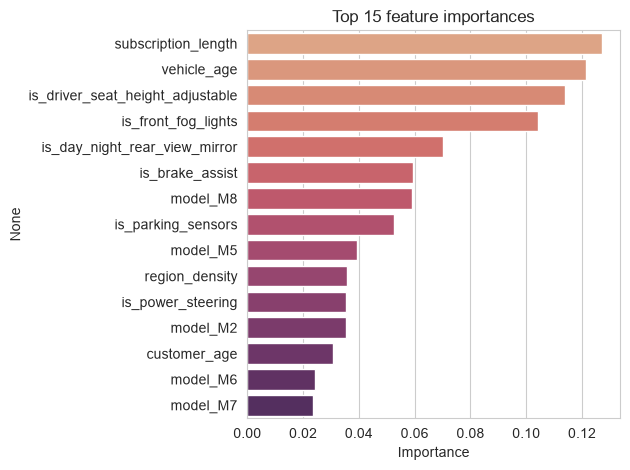

In [74]:
sns.barplot(x= importances.values[: 15], y = importances.index[: 15], palette= "flare")

plt.title("Top 15 feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [73]:
import joblib

joblib.dump(best_model, "claim_model.pkl")
joblib.dump(x_train.columns.tolist(), "model_columns.pkl")
joblib.dump(sorted(df_clean["model"].unique().tolist()),"model_options.pkl")

['model_options.pkl']